In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ecommerce_sales_dataset.csv")

print(df.head())
print("\nShape:", df.shape)

     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREE

In [34]:
# Dataset Information

print("Dataset Information")
print("-" * 50)
print(df.info())

print("\nStatistical Summary")
print("-" * 50)
print(df.describe())

print("\nMissing Values")
print("-" * 50)
print(df.isnull().sum())

print("\nDuplicate Rows")
print("-" * 50)
print(df.duplicated().sum())

Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB
None

Statistical Sum

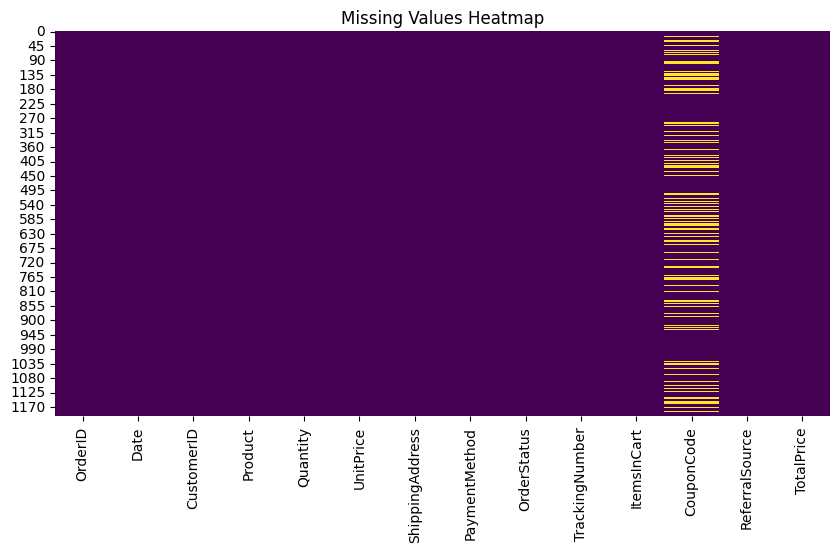

In [35]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()

In [36]:
print(df.dtypes)

OrderID             object
Date                object
CustomerID          object
Product             object
Quantity             int64
UnitPrice          float64
ShippingAddress     object
PaymentMethod       object
OrderStatus         object
TrackingNumber      object
ItemsInCart          int64
CouponCode          object
ReferralSource      object
TotalPrice         float64
dtype: object


In [37]:
df["CouponCode"] = df["CouponCode"].fillna("NoCoupon")

print(df.isnull().sum())

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [38]:
df = df.drop(
    columns=[
        "OrderID",
        "TrackingNumber",
        "Date"
    ]
)

print(df.head())
print(df.shape)

  CustomerID  Product  Quantity  UnitPrice ShippingAddress PaymentMethod  \
0     C72649  Monitor         5     570.62     928 Main St    Debit Card   
1     C75739    Phone         2     151.35     823 Main St        Online   
2     C81728   Tablet         5     550.68     512 Main St   Credit Card   
3     C33540    Chair         1     273.19     275 Main St    Debit Card   
4     C81840  Printer         4     626.01     668 Main St        Online   

  OrderStatus  ItemsInCart CouponCode ReferralSource  TotalPrice  
0     Shipped            7     SAVE10      Instagram     2853.10  
1     Shipped            3     SAVE10       Referral      302.70  
2   Cancelled            8   FREESHIP          Email     2753.40  
3    Returned            5     SAVE10       Facebook      273.19  
4   Delivered            8     SAVE10          Email     2504.04  
(1200, 11)


In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   CustomerID  Product  Quantity  UnitPrice  ShippingAddress  PaymentMethod  \
0         856        3         5     570.62              596              2   
1         888        4         2     151.35              512              4   
2         950        6         5     550.68              294              1   
3         332        0         1     273.19              124              2   
4         951        5         4     626.01              407              4   

   OrderStatus  ItemsInCart  CouponCode  ReferralSource  TotalPrice  
0            4            7           2               3     2853.10  
1            4            3           2               4      302.70  
2            0            8           0               0     2753.40  
3            3            5           2               1      273.19  
4            1            8           2               0     2504.04  


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

print(scaled_data.shape)

(1200, 11)


In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

print(pca_data.shape)

(1200, 2)


In [42]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Retained:")
print(sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.20761208 0.12108218]

Total Variance Retained:
0.32869426082302566


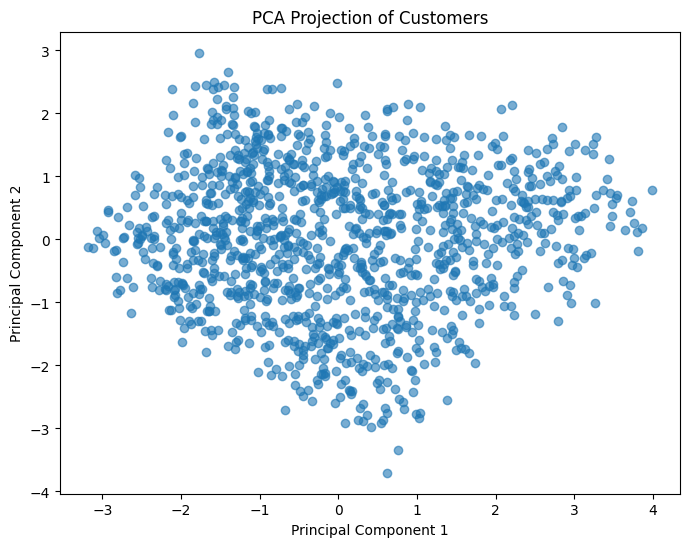

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    alpha=0.6
)

plt.title("PCA Projection of Customers")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [44]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

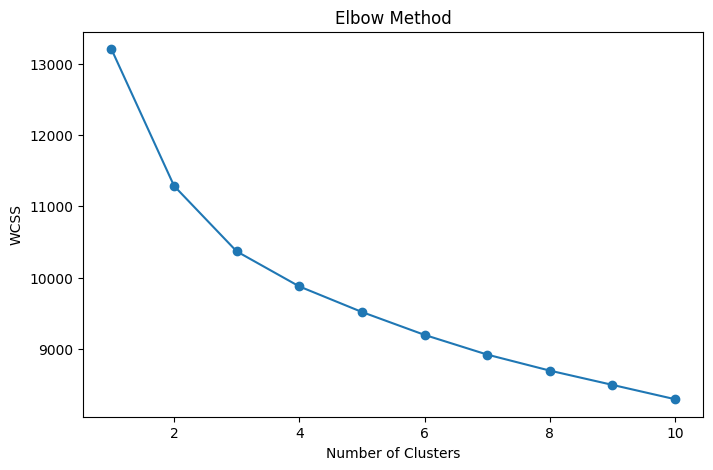

In [45]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [46]:
kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

print(clusters[:20])

[0 2 0 2 0 2 2 1 2 0 0 1 2 2 2 2 2 2 2 1]


In [47]:
df["Cluster"] = clusters

print(df.head())

   CustomerID  Product  Quantity  UnitPrice  ShippingAddress  PaymentMethod  \
0         856        3         5     570.62              596              2   
1         888        4         2     151.35              512              4   
2         950        6         5     550.68              294              1   
3         332        0         1     273.19              124              2   
4         951        5         4     626.01              407              4   

   OrderStatus  ItemsInCart  CouponCode  ReferralSource  TotalPrice  Cluster  
0            4            7           2               3     2853.10        0  
1            4            3           2               4      302.70        2  
2            0            8           0               0     2753.40        0  
3            3            5           2               1      273.19        2  
4            1            8           2               0     2504.04        0  


In [48]:
print(df["Cluster"].value_counts())

Cluster
2    549
0    349
1    302
Name: count, dtype: int64


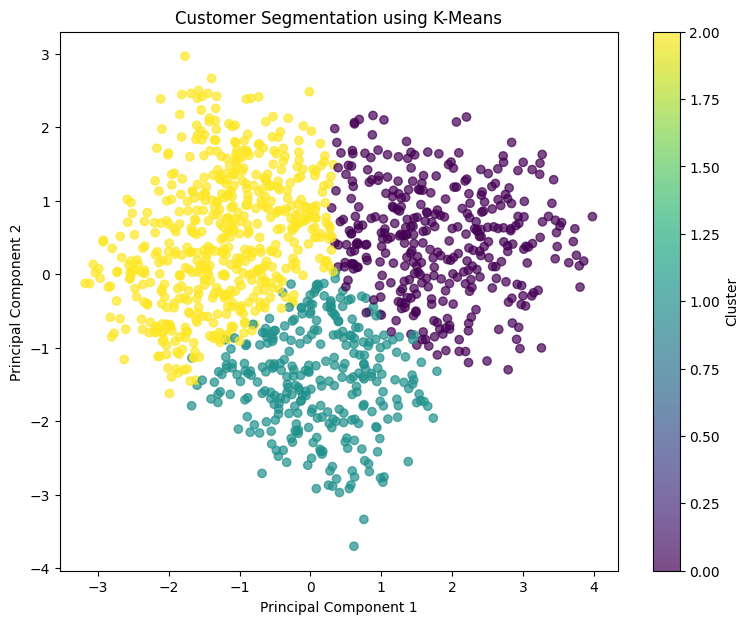

In [49]:
plt.figure(figsize=(9,7))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters,
    cmap="viridis",
    alpha=0.7
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.show()

In [50]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

print(cluster_summary)

         CustomerID   Product  Quantity   UnitPrice  ShippingAddress  \
Cluster                                                                
0        645.524355  3.034384  4.063037  531.767536       335.919771   
1        592.473510  2.407285  3.940397  175.327185       302.986755   
2        563.836066  3.318761  1.688525  344.553042       339.850638   

         PaymentMethod  OrderStatus  ItemsInCart  CouponCode  ReferralSource  \
Cluster                                                                        
0             1.991404     1.936963     6.865330    1.409742        1.945559   
1             1.804636     1.854305     6.947020    1.503311        1.877483   
2             2.149362     2.094718     3.803279    1.477231        2.056466   

          TotalPrice  
Cluster               
0        2133.518997  
1         681.010364  
2         572.857377  
